In [27]:
!pip install hvplot

# **Importing Required Libraries**

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import holoviews as hv
import hvplot.pandas

# **Exploratory Data Analysis (EDA)**

In [29]:
visitors = pd.read_csv("https://tinyurl.com/ChrisCoDV/001357481/CinemaWeeklyVisitors.csv", index_col=0)
age = pd.read_csv("https://tinyurl.com/ChrisCoDV/001357481/CinemaAge.csv", index_col=0)
capacity = pd.read_csv("https://tinyurl.com/ChrisCoDV/001357481/CinemaCapacity.csv", index_col=0)
marketing = pd.read_csv("https://tinyurl.com/ChrisCoDV/001357481/CinemaMarketing.csv", index_col=0)
overheads = pd.read_csv("https://tinyurl.com/ChrisCoDV/001357481/CinemaOverheads.csv", index_col=0)
spend = pd.read_csv("https://tinyurl.com/ChrisCoDV/001357481/CinemaSpend.csv", index_col=0)

In [30]:
summary_data = pd.DataFrame(index=visitors.columns)
summary_data['Total Visitors'] = visitors.sum().values
summary_data['Age'] = age.values
summary_data['Capacity'] = capacity.values
summary_data['Overheads'] = overheads.values
summary_data['Marketing'] = marketing.values
summary_data['Spend'] = spend.values
print(summary_data.head())


     Total Visitors  Age  Capacity  Overheads  Marketing  Spend
TJN           95487   32       380         17         13     18
TPY          101698   27       150         44          7      9
UDD           74111   37       184         50          9     15
VJV          196061   41       548         76         28     12
TVJ           64015   29        93         11         10     13


In [31]:
print(visitors.head())
print(visitors.tail())
visitors.shape

            TJN  TPY  UDD   VJV  TVJ  WKL  JJQ  ACQ  AKA  YKT  ...  XEZ  YCI  \
Date                                                           ...             
2019-01-01  414  513  399  1011  320  118  151  182    0  175  ...  128  113   
2019-01-08  453  577  334  1247  346  124  169  162    0  151  ...  205  142   
2019-01-15  486  567  346   917  321  135  145  217    0  155  ...  161  115   
2019-01-22  431  535  374   963  346  122  175  160    0  139  ...  175  134   
2019-01-29  430  391  323   846  339  126  147  149    0  175  ...  154  136   

            RPQ  VPG  CWN  WQW  UVQ  BWF   YBS  WBK  
Date                                                 
2019-01-01  302  952    0  204  346  187  1028  519  
2019-01-08  305  826    0  136  431  191   987  512  
2019-01-15  325  960    0  209  410  183   953  516  
2019-01-22  312  843    0  174  511  188   931  506  
2019-01-29  283  909    0  162  365  185   774  507  

[5 rows x 30 columns]
            TJN  TPY  UDD   VJV  TVJ  

(209, 30)

In [32]:
print(age.head())

     Avg age (yrs)
Id                
TJN             32
TPY             27
UDD             37
VJV             41
TVJ             29


In [33]:
print(capacity.head())

     Seating capacity
Id                   
TJN               380
TPY               150
UDD               184
VJV               548
TVJ                93


In [34]:
print(marketing.head())

     Marketing (£000s)
Id                    
TJN                 13
TPY                  7
UDD                  9
VJV                 28
TVJ                 10


In [35]:
print(overheads.head())

     Overheads (£000s)
Id                    
TJN                 17
TPY                 44
UDD                 50
VJV                 76
TVJ                 11


In [36]:
print(spend.head())

     Avg spend (£)
Id                
TJN             18
TPY              9
UDD             15
VJV             12
TVJ             13


# **Time Series Dataframe**

# **1. Bar Graph for all Cinemas**

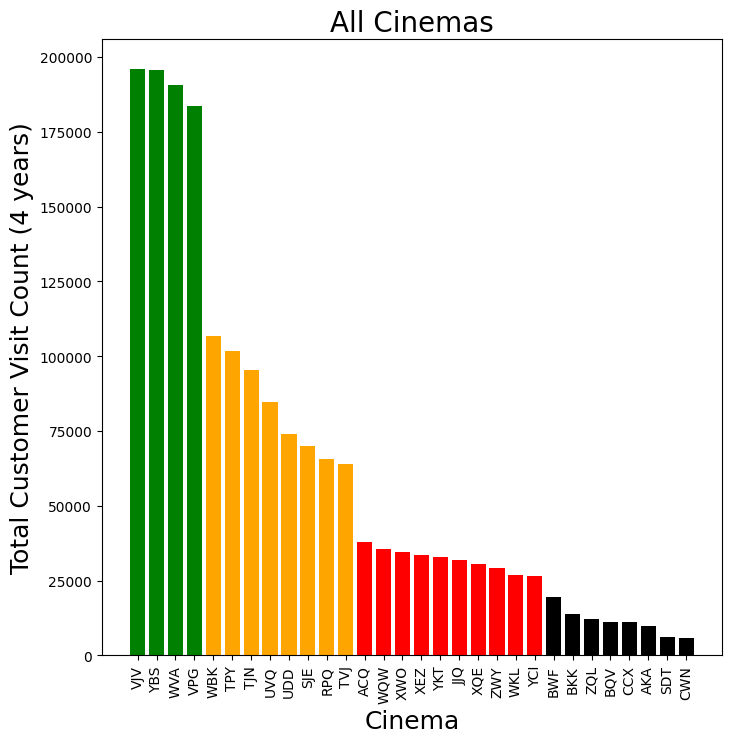

In [38]:
colours = []
for name in visitors.columns:
    total_count = visitors[name].sum()
    if total_count > 150000:
        colour = 'green'
    elif total_count >= 60000:
        colour = 'orange'
    elif total_count >= 25000:
        colour = 'red'
    else:
        colour = 'black'
    colours.append(colour)


visitors = visitors.reindex(visitors.sum().sort_values(ascending=False).index, axis=1)
plt.figure(figsize=(8, 8))
x_pos = np.arange(len(visitors.columns))
plt.bar(x_pos,visitors.sum(), align='center', color=colours)
plt.xticks(x_pos, visitors.columns, rotation=90)
plt.xlabel('Cinema', fontsize=18)
plt.ylabel('Total Customer Visit Count (4 years)', fontsize=18)
plt.title('All Cinemas', fontsize=20)
plt.show()

# **2. Line Plot for all Cinemas**

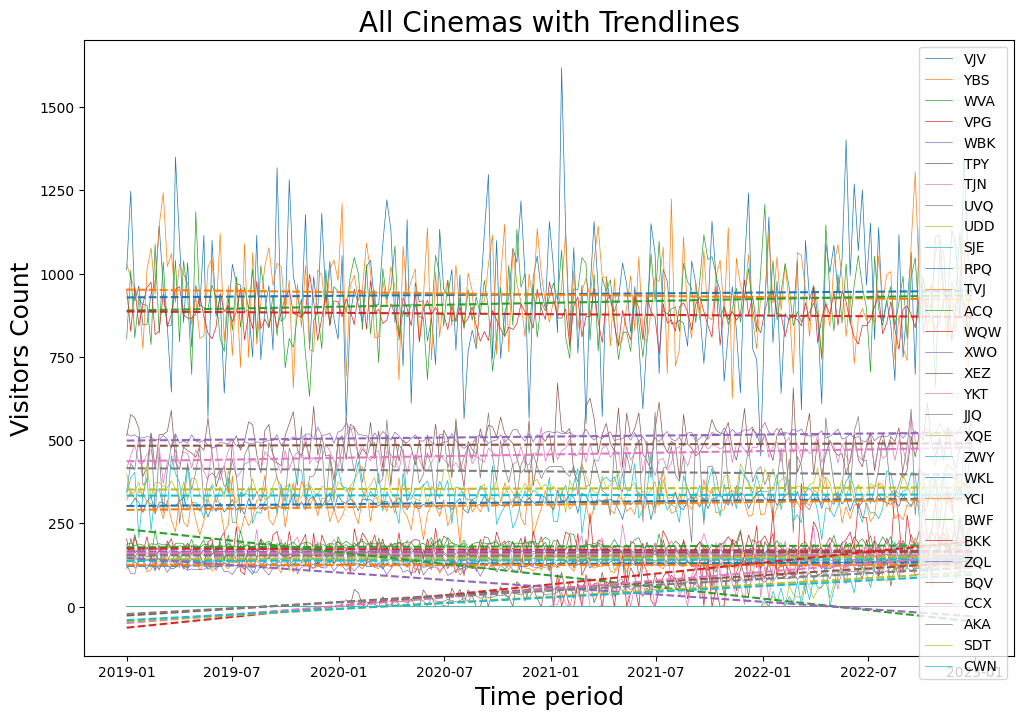

In [39]:
visitors.index = pd.to_datetime(visitors.index)

plt.figure(figsize=(12, 8))
plt.plot(visitors, linewidth=0.5)
plt.gca().set_prop_cycle(None)
for name in visitors:
    x = np.arange(len(visitors[name]))
    z = np.polyfit(x, visitors[name], 1)
    trend = np.poly1d(z)
    plt.plot(visitors.index, trend(x), linestyle='--')
plt.xlabel('Time period', fontsize=18)
plt.ylabel('Visitors Count', fontsize=18)
plt.title('All Cinemas'
    + ' with Trendlines', fontsize=20)
plt.legend(visitors, loc=1)
plt.show()

# **3. Line Plot for Very Low Popularity Cinemas**



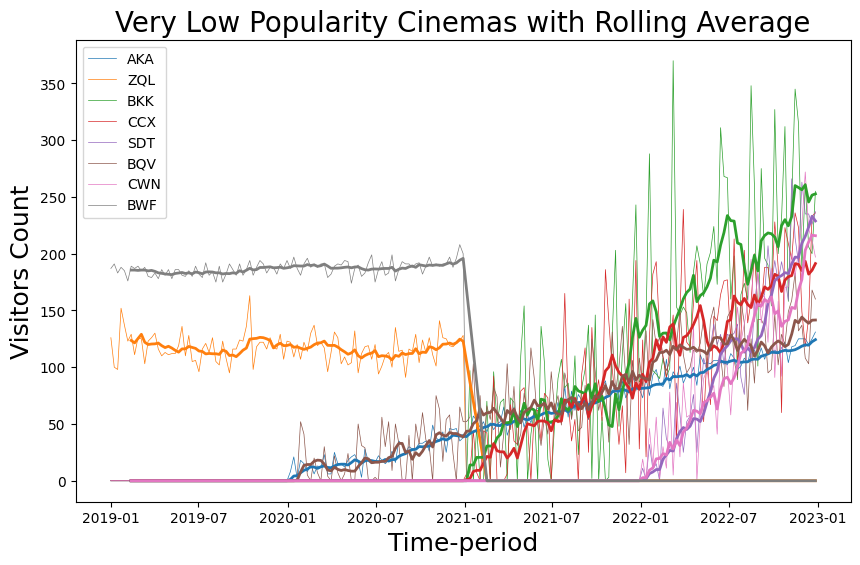

In [40]:
period = 7
rolling_average = visitors.rolling(window=period).mean()
visitors.index = pd.to_datetime(visitors.index)


selected = ['AKA', 'ZQL', 'BKK', 'CCX', 'SDT', 'BQV', 'CWN', 'BWF']

plt.figure(figsize=(10, 6))
plt.plot(visitors[selected], linewidth=0.5)
plt.gca().set_prop_cycle(None)
plt.plot(rolling_average[selected],linewidth=2)
plt.xlabel('Time-period', fontsize=18)
plt.ylabel('Visitors Count', fontsize=18)
plt.title('Very Low Popularity Cinemas with Rolling Average',
    fontsize=20)
plt.legend(visitors[selected], loc=2)
plt.show()


# **4. Autocorrelation**

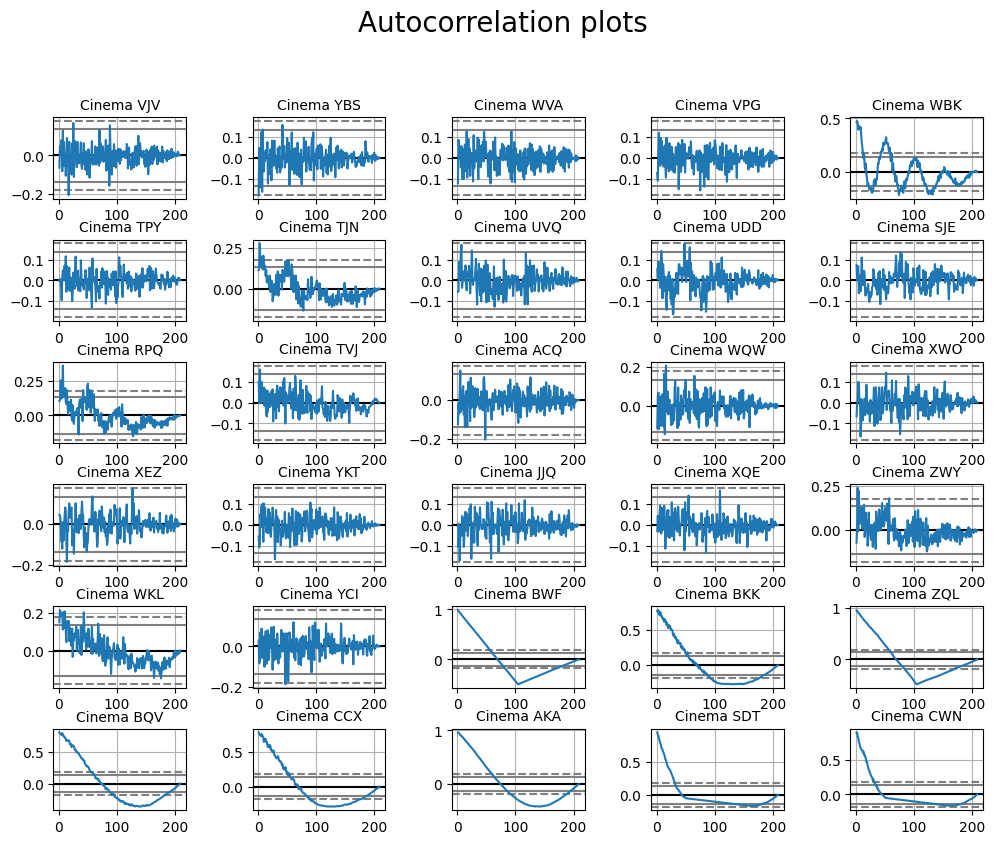

In [41]:
row = 0
col = 0
fig, axes = plt.subplots(figsize=(12, 9), nrows=6, ncols=5)
fig.suptitle('Autocorrelation plots', fontsize=20, position=(0.5, 1.0))
for name in visitors.columns:
    sub = pd.plotting.autocorrelation_plot(visitors[name], axes[row, col])
    sub.set_title('Cinema ' + name, fontsize=10)
    sub.xaxis.label.set_visible(False)
    sub.yaxis.label.set_visible(False)
    col += 1
    if col == 5:
        row += 1
        col = 0
plt.subplots_adjust(wspace=0.5, hspace=0.5)
plt.show()


# **Summary Dataframe**

# **5. Heat Map for Summary Data (Interative)**

/usr/local/lib/python3.10/dist-packages/holoviews/core/util.py:1585: PanelDeprecationWarning: 'param_value_if_widget' is deprecated and will be removed in version 1.4, use 'transform_reference' instead.
  value = param_value_if_widget(value)
/usr/local/lib/python3.10/dist-packages/holoviews/core/util.py:1585: PanelDeprecationWarning: 'param_value_if_widget' is deprecated and will be removed in version 1.4, use 'transform_reference' instead.
  value = param_value_if_widget(value)
/usr/local/lib/python3.10/dist-packages/holoviews/core/util.py:1585: PanelDeprecationWarning: 'param_value_if_widget' is deprecated and will be removed in version 1.4, use 'transform_reference' instead.
  value = param_value_if_widget(value)
/usr/local/lib/python3.10/dist-packages/holoviews/core/util.py:1585: PanelDeprecationWarning: 'param_value_if_widget' is deprecated and will be removed in version 1.4, use 'transform_reference' instead.
  value = param_value_if_widget(value)
/usr/local/lib/python3.10/dist-p

<img src='data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAEAAAABACAYAAACqaXHeAAAABHNCSVQICAgIfAhkiAAAAAlwSFlz
AAAB+wAAAfsBxc2miwAAABl0RVh0U29mdHdhcmUAd3d3Lmlua3NjYXBlLm9yZ5vuPBoAAA6zSURB
VHic7ZtpeFRVmsf/5966taWqUlUJ2UioBBJiIBAwCZtog9IOgjqACsogKtqirT2ttt069nQ/zDzt
tI4+CrJIREFaFgWhBXpUNhHZQoKBkIUASchWla1S+3ar7r1nPkDaCAnZKoQP/D7mnPOe9/xy76n3
nFSAW9ziFoPFNED2LLK5wcyBDObkb8ZkxuaoSYlI6ZcOKq1eWFdedqNzGHQBk9RMEwFAASkk0Xw3
ETacDNi2vtvc7L0ROdw0AjoSotQVkKSvHQz/wRO1lScGModBFbDMaNRN1A4tUBCS3lk7BWhQkgpD
lG4852/+7DWr1R3uHAZVQDsbh6ZPN7CyxUrCzJMRouusj0ipRwD2uKm0Zn5d2dFwzX1TCGhnmdGo
G62Nna+isiUqhkzuKrkQaJlPEv5mFl2fvGg2t/VnzkEV8F5ioioOEWkLG86fvbpthynjdhXYZziQ
x1hC9J2NFyi8vCTt91Fh04KGip0AaG9zuCk2wQCVyoNU3Hjezee9bq92duzzTmxsRJoy+jEZZZYo
GTKJ6SJngdJqAfRzpze0+jHreUtPc7gpBLQnIYK6BYp/uGhw9YK688eu7v95ysgshcg9qSLMo3JC
4jqLKQFBgdKDPoQ+Pltb8dUyQLpeDjeVgI6EgLIQFT5tEl3rn2losHVsexbZ3EyT9wE1uGdkIPcy
BGxn8QUq1QrA5nqW5i2tLqvrrM9NK6AdkVIvL9E9bZL/oyfMVd/jqvc8LylzRBKDJSzIExwhQzuL
QYGQj4rHfFTc8mUdu3E7yoLtbTe9gI4EqVgVkug2i5+uXGo919ixbRog+3fTbQ8qJe4ZOYNfMoTI
OoshUNosgO60AisX15aeI2PSIp5KiFLI9ubb1vV3Qb2ltwLakUCDAkWX7/nHKRmmGIl9VgYsUhJm
2NXjKYADtM1ygne9QQDIXlk49FBstMKx66D1v4+XuQr7vqTe0VcBHQlRWiOCbmmSYe2SqtL6q5rJ
zsTb7lKx3FKOYC4DoqyS/B5bvLPxvD9Qtf6saxYLQGJErmDOdOMr/zo96km1nElr8bmPOBwI9COv
HnFPRIwmkSOv9kcAS4heRsidOkpeWBgZM+UBrTFAXNYL5Vf2ii9c1trNzpYdaoVil3WIc+wdk+gQ
noie3ecCcxt9ITcLAPWt/laGEO/9U6PmzZkenTtsSMQ8uYywJVW+grCstAvCIaAdArAsIWkRDDs/
KzLm2YcjY1Lv0UdW73HabE9n6V66cxSzfEmuJssTpKGVp+0vHq73FwL46eOjpMpbRAnNmJFrGJNu
Ukf9Yrz+3rghiumCKNXXWPhLYcjxGsIpoCMsIRoFITkW8AuyM8jC1+/QLx4bozCEJIq38+1rtpR6
V/yzb8eBlRb3fo5l783N0CWolAzJHaVNzkrTzlEp2bQ2q3TC5gn6wpnoQAmwSiGh2GitnTmVMc5O
UyfKWUKCIsU7+fZDKwqdT6DDpvkzAX4/+AMFjk0tDp5GRXLpQ2MUmhgDp5gxQT8+Y7hyPsMi8uxF
71H0oebujHALECjFKaW9Lm68n18wXp2kVzIcABytD5iXFzg+WVXkegpAsOOYziqo0OkK76GyquC3
ltZAzMhhqlSNmmWTE5T6e3IN05ITFLM4GdN0vtZ3ob8Jh1NAKXFbm5PtLU/eqTSlGjkNAJjdgn/N
aedXa0tdi7+t9G0FIF49rtMSEgAs1kDLkTPO7ebm4IUWeyh1bKomXqlgMG6kJmHcSM0clYLJ8XtR
1GTnbV3F6I5wCGikAb402npp1h1s7LQUZZSMIfALFOuL3UUrfnS8+rez7v9qcold5tilgHbO1fjK
9ubb17u9oshxzMiUBKXWqJNxd+fqb0tLVs4lILFnK71H0Ind7uiPgACVcFJlrb0tV6DzxqqTIhUM
CwDf1/rrVhTa33/3pGPxJYdQ2l2cbgVcQSosdx8uqnDtbGjh9SlDVSMNWhlnilfqZk42Th2ZpLpf
xrHec5e815zrr0dfBZSwzkZfqsv+1FS1KUknUwPARVvItfKUY+cn57yP7qv07UE3p8B2uhUwLk09
e0SCOrK+hbdYHYLjRIl71wWzv9jpEoeOHhGRrJAzyEyNiJuUqX0g2sBN5kGK6y2Blp5M3lsB9Qh4
y2Ja6x6+i0ucmKgwMATwhSjdUu49tKrQ/pvN5d53ml2CGwCmJipmKjgmyuaXzNeL2a0AkQ01Th5j
2DktO3Jyk8f9vcOBQHV94OK+fPumJmvQHxJoWkaKWq9Vs+yUsbq0zGT1I4RgeH2b5wef7+c7bl8F
eKgoHVVZa8ZPEORzR6sT1BzDUAD/d9F78e2Tzv99v8D+fLVTqAKAsbGamKey1Mt9Ann4eH3gTXTz
idWtAJ8PQWOk7NzSeQn/OTHDuEikVF1R4z8BQCy+6D1aWRfY0tTGG2OM8rRoPaeIj5ZHzJxszElN
VM8K8JS5WOfv8mzRnQAKoEhmt8gyPM4lU9SmBK1MCQBnW4KONT86v1hZ1PbwSXPw4JWussVjtH9Y
NCoiL9UoH/6PSu8jFrfY2t36erQHXLIEakMi1SydmzB31h3GGXFDFNPaK8Rme9B79Ixrd0WN+1ij
NRQ/doRmuFLBkHSTOm5GruG+pFjFdAmorG4IXH1Qua6ASniclfFtDYt+oUjKipPrCQB7QBQ2lrgP
fFzm+9XWUtcqJ3/5vDLDpJ79XHZk3u8nGZ42qlj1+ydtbxysCezrydp6ugmipNJ7WBPB5tydY0jP
HaVNzs3QzeE4ZpTbI+ZbnSFPbVOw9vsfnVvqWnirPyCNGD08IlqtYkh2hjZ5dErEQzoNm+6ykyOt
Lt5/PQEuSRRKo22VkydK+vvS1XEKlhCJAnsqvcVvH7f/ZU2R67eXbMEGAMiIV5oWZWiWvz5Fv2xG
sjqNJQRvn3Rs2lji/lNP19VjAQDgD7FHhujZB9OGqYxRkZxixgRDVlqS6uEOFaJUVu0rPFzctrnF
JqijImVp8dEKVWyUXDk92zAuMZ6bFwpBU1HrOw6AdhQgUooChb0+ItMbWJitSo5Ws3IAOGEOtL53
0vHZih9sC4vtofZ7Qu6523V/fmGcds1TY3V36pUsBwAbSlxnVh2xLfAD/IAIMDf7XYIkNmXfpp2l
18rkAJAy9HKFaIr/qULkeQQKy9zf1JgDB2uaeFNGijo5QsUyacNUUTOnGO42xSnv4oOwpDi1zYkc
efUc3I5Gk6PhyTuVKaOGyLUAYPGIoY9Pu/atL/L92+4q9wbflRJ2Trpm/jPjdBtfnqB/dIThcl8A
KG7hbRuKnb8qsQsVvVlTrwQAQMUlf3kwJI24Z4JhPMtcfng5GcH49GsrxJpGvvHIaeem2ma+KSjQ
lIwUdYyCY8j4dE1KzijNnIP2llF2wcXNnsoapw9XxsgYAl6k+KzUXbi2yP3KR2ecf6z3BFsBICdW
nvnIaG3eHybqX7vbpEqUMT+9OL4Qpe8VON7dXuFd39v19FoAABRVePbGGuXTszO0P7tu6lghUonE
llRdrhArLvmKdh9u29jcFiRRkfLUxBiFNiqSU9icoZQHo5mYBI1MBgBH6wMNb+U7Pnw337H4gi1Y
ciWs+uks3Z9fztUvfzxTm9Ne8XXkvQLHNytOOZeiD4e0PgkAIAYCYknKUNUDSXEKzdWNpnil7r4p
xqkjTarZMtk/K8TQ6Qve78qqvXurGwIJqcOUKfUWHsm8KGvxSP68YudXq4pcj39X49uOK2X142O0
Tz5/u/7TVybqH0rSya6ZBwD21/gubbrgWdDgEOx9W
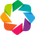

:HeatMap   [columns,index]   (value)

In [42]:
plot = summary_data.corr().hvplot.heatmap(
    frame_height=500, frame_width=500,
    title='Summary data correlations',
    rot=90, cmap='coolwarm'
).opts(invert_yaxis=True, clim=(-1, 1))

hv.extension('bokeh')
plot

The interactive heat map plot contains 6 user interaction tool, namely, Pan, Box Zoom, Wheel Zoom, Save, Reset and Hover.

How to use:-

**Pan**: This tool is used to move the plot vertically and horizontally. It has also got the option to move horizontal only and vertical only. Click on a portion of the heat map and move the map according to the option selected.

**Box Zoom**: This tool is used to zoom the plot in a selected area. It has also got the options to zoom the plot in x- dimension only and y-dimension only. Select a portion of the heat map with the mouse to zoom in according to the option of the box zoom selected.

**Wheel Zoom**: This tool is used to zoom in and out a portion where the cursor is placed. Place the cursor on the position to zoom in/out and roll the roller up and down to zoom in and out respectively.

**Save**: This tool is used to save the plot into our system as png format by clicking on the save button.

**Reset**: This tool is used to reset all the previous interactions done on the plot by clicking on the reset button.

**Hover**: This tool is used to gather informations such as column, index and value of each correlation box by moving the cursor on the specific box.

# **6. Scatter Plot for Capacity vs Total Visitors with Linear Regression**

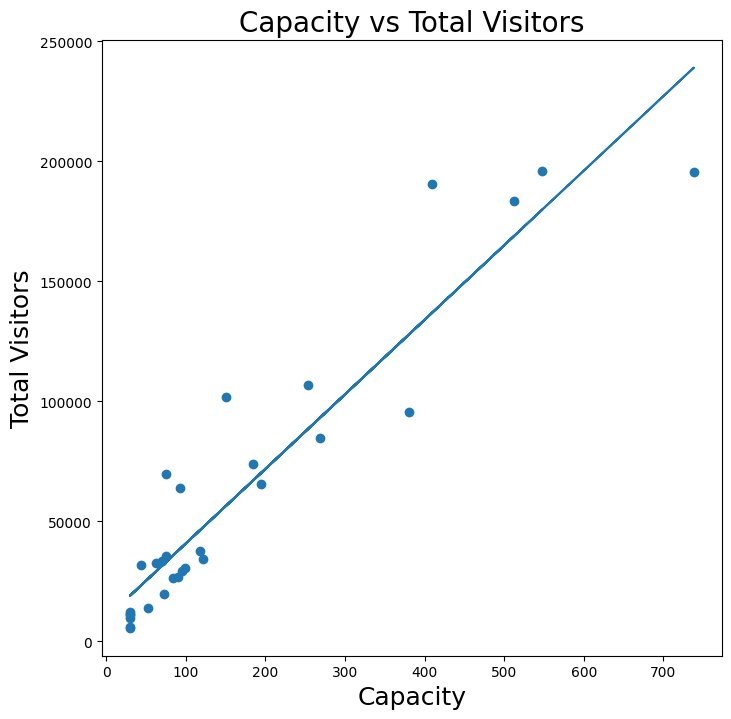

In [43]:
plt.figure(figsize=(8, 8))
plt.scatter(summary_data['Capacity'], summary_data['Total Visitors'])
z = np.polyfit(summary_data['Capacity'], summary_data['Total Visitors'], 1)
trend = np.poly1d(z)
plt.plot(summary_data['Capacity'], trend(summary_data['Capacity']))
plt.title('Capacity vs Total Visitors', fontsize=20)
plt.xlabel('Capacity', fontsize=18)
plt.ylabel('Total Visitors', fontsize=18)
plt.show()

# **7. Scatter Plot Marketing Spend vs Total Visitors**

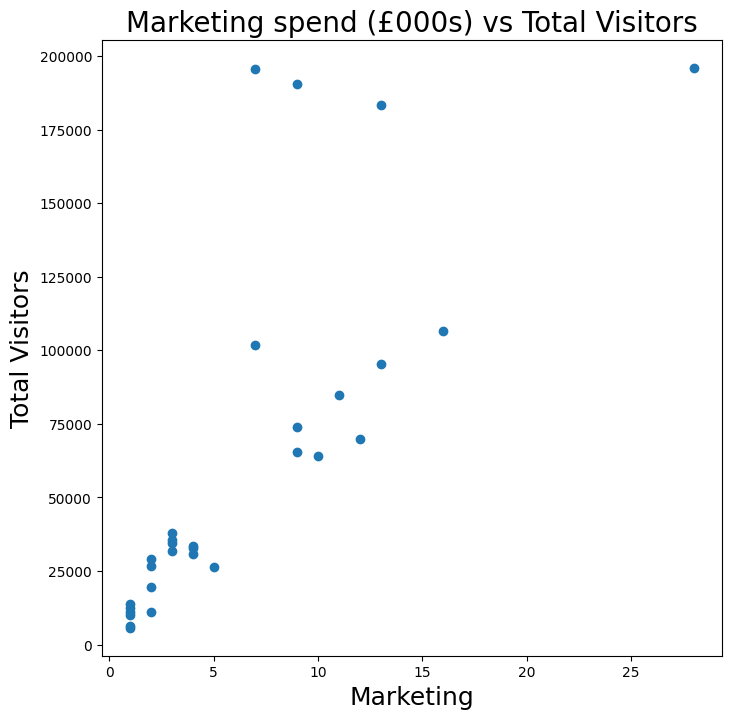

In [44]:
plt.figure(figsize=(8, 8))
plt.scatter(summary_data['Marketing'], summary_data['Total Visitors'])
plt.title('Marketing spend (£000s) vs Total Visitors', fontsize=20)
plt.xlabel('Marketing', fontsize=18)
plt.ylabel('Total Visitors', fontsize=18)
plt.show()

# **8. Box Plot for Summary Data (Interactive)**

/usr/local/lib/python3.10/dist-packages/holoviews/core/util.py:1585: PanelDeprecationWarning: 'param_value_if_widget' is deprecated and will be removed in version 1.4, use 'transform_reference' instead.
  value = param_value_if_widget(value)
/usr/local/lib/python3.10/dist-packages/holoviews/core/util.py:1585: PanelDeprecationWarning: 'param_value_if_widget' is deprecated and will be removed in version 1.4, use 'transform_reference' instead.
  value = param_value_if_widget(value)
/usr/local/lib/python3.10/dist-packages/holoviews/core/util.py:1585: PanelDeprecationWarning: 'param_value_if_widget' is deprecated and will be removed in version 1.4, use 'transform_reference' instead.
  value = param_value_if_widget(value)
/usr/local/lib/python3.10/dist-packages/holoviews/core/util.py:1585: PanelDeprecationWarning: 'param_value_if_widget' is deprecated and will be removed in version 1.4, use 'transform_reference' instead.
  value = param_value_if_widget(value)
/usr/local/lib/python3.10/dist-p

<img src='data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAEAAAABACAYAAACqaXHeAAAABHNCSVQICAgIfAhkiAAAAAlwSFlz
AAAB+wAAAfsBxc2miwAAABl0RVh0U29mdHdhcmUAd3d3Lmlua3NjYXBlLm9yZ5vuPBoAAA6zSURB
VHic7ZtpeFRVmsf/5966taWqUlUJ2UioBBJiIBAwCZtog9IOgjqACsogKtqirT2ttt069nQ/zDzt
tI4+CrJIREFaFgWhBXpUNhHZQoKBkIUASchWla1S+3ar7r1nPkDaCAnZKoQP/D7mnPOe9/xy76n3
nFSAW9ziFoPFNED2LLK5wcyBDObkb8ZkxuaoSYlI6ZcOKq1eWFdedqNzGHQBk9RMEwFAASkk0Xw3
ETacDNi2vtvc7L0ROdw0AjoSotQVkKSvHQz/wRO1lScGModBFbDMaNRN1A4tUBCS3lk7BWhQkgpD
lG4852/+7DWr1R3uHAZVQDsbh6ZPN7CyxUrCzJMRouusj0ipRwD2uKm0Zn5d2dFwzX1TCGhnmdGo
G62Nna+isiUqhkzuKrkQaJlPEv5mFl2fvGg2t/VnzkEV8F5ioioOEWkLG86fvbpthynjdhXYZziQ
x1hC9J2NFyi8vCTt91Fh04KGip0AaG9zuCk2wQCVyoNU3Hjezee9bq92duzzTmxsRJoy+jEZZZYo
GTKJ6SJngdJqAfRzpze0+jHreUtPc7gpBLQnIYK6BYp/uGhw9YK688eu7v95ysgshcg9qSLMo3JC
4jqLKQFBgdKDPoQ+Pltb8dUyQLpeDjeVgI6EgLIQFT5tEl3rn2losHVsexbZ3EyT9wE1uGdkIPcy
BGxn8QUq1QrA5nqW5i2tLqvrrM9NK6AdkVIvL9E9bZL/oyfMVd/jqvc8LylzRBKDJSzIExwhQzuL
QYGQj4rHfFTc8mUdu3E7yoLtbTe9gI4EqVgVkug2i5+uXGo919ixbRog+3fTbQ8qJe4ZOYNfMoTI
OoshUNosgO60AisX15aeI2PSIp5KiFLI9ubb1vV3Qb2ltwLakUCDAkWX7/nHKRmmGIl9VgYsUhJm
2NXjKYADtM1ygne9QQDIXlk49FBstMKx66D1v4+XuQr7vqTe0VcBHQlRWiOCbmmSYe2SqtL6q5rJ
zsTb7lKx3FKOYC4DoqyS/B5bvLPxvD9Qtf6saxYLQGJErmDOdOMr/zo96km1nElr8bmPOBwI9COv
HnFPRIwmkSOv9kcAS4heRsidOkpeWBgZM+UBrTFAXNYL5Vf2ii9c1trNzpYdaoVil3WIc+wdk+gQ
noie3ecCcxt9ITcLAPWt/laGEO/9U6PmzZkenTtsSMQ8uYywJVW+grCstAvCIaAdArAsIWkRDDs/
KzLm2YcjY1Lv0UdW73HabE9n6V66cxSzfEmuJssTpKGVp+0vHq73FwL46eOjpMpbRAnNmJFrGJNu
Ukf9Yrz+3rghiumCKNXXWPhLYcjxGsIpoCMsIRoFITkW8AuyM8jC1+/QLx4bozCEJIq38+1rtpR6
V/yzb8eBlRb3fo5l783N0CWolAzJHaVNzkrTzlEp2bQ2q3TC5gn6wpnoQAmwSiGh2GitnTmVMc5O
UyfKWUKCIsU7+fZDKwqdT6DDpvkzAX4/+AMFjk0tDp5GRXLpQ2MUmhgDp5gxQT8+Y7hyPsMi8uxF
71H0oebujHALECjFKaW9Lm68n18wXp2kVzIcABytD5iXFzg+WVXkegpAsOOYziqo0OkK76GyquC3
ltZAzMhhqlSNmmWTE5T6e3IN05ITFLM4GdN0vtZ3ob8Jh1NAKXFbm5PtLU/eqTSlGjkNAJjdgn/N
aedXa0tdi7+t9G0FIF49rtMSEgAs1kDLkTPO7ebm4IUWeyh1bKomXqlgMG6kJmHcSM0clYLJ8XtR
1GTnbV3F6I5wCGikAb402npp1h1s7LQUZZSMIfALFOuL3UUrfnS8+rez7v9qcold5tilgHbO1fjK
9ubb17u9oshxzMiUBKXWqJNxd+fqb0tLVs4lILFnK71H0Ind7uiPgACVcFJlrb0tV6DzxqqTIhUM
CwDf1/rrVhTa33/3pGPxJYdQ2l2cbgVcQSosdx8uqnDtbGjh9SlDVSMNWhlnilfqZk42Th2ZpLpf
xrHec5e815zrr0dfBZSwzkZfqsv+1FS1KUknUwPARVvItfKUY+cn57yP7qv07UE3p8B2uhUwLk09
e0SCOrK+hbdYHYLjRIl71wWzv9jpEoeOHhGRrJAzyEyNiJuUqX0g2sBN5kGK6y2Blp5M3lsB9Qh4
y2Ja6x6+i0ucmKgwMATwhSjdUu49tKrQ/pvN5d53ml2CGwCmJipmKjgmyuaXzNeL2a0AkQ01Th5j
2DktO3Jyk8f9vcOBQHV94OK+fPumJmvQHxJoWkaKWq9Vs+yUsbq0zGT1I4RgeH2b5wef7+c7bl8F
eKgoHVVZa8ZPEORzR6sT1BzDUAD/d9F78e2Tzv99v8D+fLVTqAKAsbGamKey1Mt9Ann4eH3gTXTz
idWtAJ8PQWOk7NzSeQn/OTHDuEikVF1R4z8BQCy+6D1aWRfY0tTGG2OM8rRoPaeIj5ZHzJxszElN
VM8K8JS5WOfv8mzRnQAKoEhmt8gyPM4lU9SmBK1MCQBnW4KONT86v1hZ1PbwSXPw4JWussVjtH9Y
NCoiL9UoH/6PSu8jFrfY2t36erQHXLIEakMi1SydmzB31h3GGXFDFNPaK8Rme9B79Ixrd0WN+1ij
NRQ/doRmuFLBkHSTOm5GruG+pFjFdAmorG4IXH1Qua6ASniclfFtDYt+oUjKipPrCQB7QBQ2lrgP
fFzm+9XWUtcqJ3/5vDLDpJ79XHZk3u8nGZ42qlj1+ydtbxysCezrydp6ugmipNJ7WBPB5tydY0jP
HaVNzs3QzeE4ZpTbI+ZbnSFPbVOw9vsfnVvqWnirPyCNGD08IlqtYkh2hjZ5dErEQzoNm+6ykyOt
Lt5/PQEuSRRKo22VkydK+vvS1XEKlhCJAnsqvcVvH7f/ZU2R67eXbMEGAMiIV5oWZWiWvz5Fv2xG
sjqNJQRvn3Rs2lji/lNP19VjAQDgD7FHhujZB9OGqYxRkZxixgRDVlqS6uEOFaJUVu0rPFzctrnF
JqijImVp8dEKVWyUXDk92zAuMZ6bFwpBU1HrOw6AdhQgUooChb0+ItMbWJitSo5Ws3IAOGEOtL53
0vHZih9sC4vtofZ7Qu6523V/fmGcds1TY3V36pUsBwAbSlxnVh2xLfAD/IAIMDf7XYIkNmXfpp2l
18rkAJAy9HKFaIr/qULkeQQKy9zf1JgDB2uaeFNGijo5QsUyacNUUTOnGO42xSnv4oOwpDi1zYkc
efUc3I5Gk6PhyTuVKaOGyLUAYPGIoY9Pu/atL/L92+4q9wbflRJ2Trpm/jPjdBtfnqB/dIThcl8A
KG7hbRuKnb8qsQsVvVlTrwQAQMUlf3kwJI24Z4JhPMtcfng5GcH49GsrxJpGvvHIaeem2ma+KSjQ
lIwUdYyCY8j4dE1KzijNnIP2llF2wcXNnsoapw9XxsgYAl6k+KzUXbi2yP3KR2ecf6z3BFsBICdW
nvnIaG3eHybqX7vbpEqUMT+9OL4Qpe8VON7dXuFd39v19FoAABRVePbGGuXTszO0P7tu6lghUonE
llRdrhArLvmKdh9u29jcFiRRkfLUxBiFNiqSU9icoZQHo5mYBI1MBgBH6wMNb+U7Pnw337H4gi1Y
ciWs+uks3Z9fztUvfzxTm9Ne8XXkvQLHNytOOZeiD4e0PgkAIAYCYknKUNUDSXEKzdWNpnil7r4p
xqkjTarZMtk/K8TQ6Qve78qqvXurGwIJqcOUKfUWHsm8KGvxSP68YudXq4pcj39X49uOK2X142O0
Tz5/u/7TVybqH0rSya6ZBwD21/gubbrgWdDgEOx9W
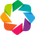

:BoxWhisker   [Variable]   (value)

In [45]:
hvplot_box = summary_data.drop(columns='Total Visitors').hvplot.box(
    width=1000,
    height=650,
    xlabel='Data',
    ylabel='Count',
    title='Summary data Box Plot',
    fontsize={'labels': 18, 'title': 20}
)

hv.extension('bokeh')
hvplot_box

The interactive box plot contains 5 user interaction tool, namely, Pan, Box Zoom, Wheel Zoom, Save and Reset.

How to use:-

**Pan**: This tool is used to move the plot vertically and horizontally. It has also got the option to move horizontal only and vertical only. Click on a portion of the box plot and move the map according to the option selected.

**Box Zoom**: This tool is used to zoom the plot in a selected area. It has also got the options to zoom the plot in x- dimension only and y-dimension only. Select a portion of the box plot with the mouse to zoom in according to the option of the box zoom selected.

**Wheel Zoom**: This tool is used to zoom in and out a portion where the cursor is placed. Place the cursor on the position to zoom in/out and roll the roller up and down to zoom in and out respectively.

**Save**: This tool is used to save the plot into our system as png format by clicking on the save button.

**Reset**: This tool is used to reset all the previous interactions done on the plot by clicking on the reset button.